# 1. Modelagem, Validação e Interpretabilidade

Este notebook concentra a etapa de Machine Learning do projeto **California Housing Market Radar**, desde a preparação dos dados para treinamento até a construção e persistência do pipeline final.

O objetivo é desenvolver um modelo capaz de estimar o valor mediano dos imóveis por região, comparando diferentes algoritmos e avaliando não apenas desempenho preditivo, mas também estabilidade, generalização e interpretabilidade.

Ao longo do notebook são realizadas:

- divisão em treino, validação e teste com estratificação auxiliar;
- aplicação e avaliação de Feature Engineering;
- construção do pipeline de pré-processamento;
- comparação entre diferentes modelos de regressão;
- otimização de hiperparâmetros com RandomizedSearchCV e Optuna;
- experimentos com Voting e Stacking;
- validação cruzada e Learning Curve;
- avaliação final no conjunto de teste;
- análise de resíduos e importância das features;
- interpretabilidade global e individual com SHAP;
- aplicação das previsões a um contexto de negócio;
- salvamento do pipeline para utilização na aplicação Streamlit.

A seleção do modelo final é baseada no conjunto das evidências obtidas ao longo dessas etapas, buscando equilibrar desempenho, estabilidade e capacidade de generalização.

# 2. Importação das Bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para manipulação dos dados, pré-processamento, treinamento dos modelos, otimização de hiperparâmetros, validação e visualização dos resultados.


In [1]:
# ================================
# Utilitários
# ================================
import time
import joblib


# ================================
# Manipulação de dados
# ================================
import numpy as np
import pandas as pd


# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns


# ================================
# Divisão, validação e otimização
# ================================
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_score,
    learning_curve
)

import optuna
import optuna.visualization as viz


# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold


# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    VotingRegressor,
    StackingRegressor
)

import xgboost as xgb


# ================================
# Avaliação dos modelos
# ================================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


# ================================
# Interpretabilidade
# ================================
import shap


print("Bibliotecas importadas com sucesso!!")

Bibliotecas importadas com sucesso!!


# 3. Leitura da Base de Dados

A base preparada nas etapas anteriores é carregada para iniciar o processo de modelagem.

Neste notebook será utilizada a mesma estrutura de dados validada durante a preparação e análise exploratória, garantindo consistência entre as diferentes etapas do projeto.

In [2]:
dados = pd.read_csv("../data/dados_housing.csv")
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia


# 4. Validação Inicial dos Dados

Antes da construção dos modelos, é realizada uma última verificação da estrutura da base, incluindo quantidade de registros, tipos das variáveis e presença de valores ausentes.

A base possui **20.640 observações e 10 variáveis**, sendo `total_quartos` a única coluna com valores ausentes. Esses valores serão tratados posteriormente dentro do pipeline de pré-processamento, evitando vazamento de informações entre os conjuntos de treino e avaliação.

In [3]:
print(f"Total de Linhas -> {dados.shape[0]}")
print(f"Total de Colunas -> {dados.shape[1]}")

Total de Linhas -> 20640
Total de Colunas -> 10


In [4]:
print(dados.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              20640 non-null  float64
 1   latitude               20640 non-null  float64
 2   idade_mediana_imoveis  20640 non-null  float64
 3   total_comodos          20640 non-null  float64
 4   total_quartos          20433 non-null  float64
 5   populacao              20640 non-null  float64
 6   domicilios             20640 non-null  float64
 7   renda_media            20640 non-null  float64
 8   valor_media_imovel     20640 non-null  float64
 9   proximidade_oceano     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.8 MB
None


In [5]:
# Mostrando os Dados Nulos
print(dados.isna().sum())

longitude                  0
latitude                   0
idade_mediana_imoveis      0
total_comodos              0
total_quartos            207
populacao                  0
domicilios                 0
renda_media                0
valor_media_imovel         0
proximidade_oceano         0
dtype: int64


# 5. Criação de Faixas para Estratificação

Como o problema é de regressão, a variável alvo `valor_media_imovel` é contínua e não pode ser utilizada diretamente em uma estratificação tradicional.

Para preservar uma distribuição semelhante dos valores entre os conjuntos de treino, validação e teste, a variável alvo foi discretizada temporariamente em **5 faixas de preço** utilizando `pd.qcut`.

Essa variável auxiliar será utilizada apenas no processo de divisão dos dados e não fará parte das features utilizadas pelos modelos.

In [6]:
dados["faixa_preco"] = pd.qcut(
    dados["valor_media_imovel"],
    q=5,
    labels=False
)

As cinco faixas apresentam quantidades muito semelhantes de registros, indicando que o `qcut` conseguiu criar grupos aproximadamente balanceados.

Isso permite utilizar `stratify` durante a separação dos dados, reduzindo o risco de concentrar faixas específicas de preço em apenas um dos conjuntos.

> A variável `faixa_preco` é derivada diretamente da variável alvo e, por isso, deve ser removida antes da modelagem para evitar data leakage.

In [7]:
dados["faixa_preco"].value_counts()

faixa_preco
2    4132
1    4129
0    4129
4    4125
3    4125
Name: count, dtype: int64

# 6. Separação das Variáveis e Divisão dos Dados

Nesta etapa, a variável alvo `valor_media_imovel` é separada das variáveis explicativas e os dados são divididos em conjuntos de treino, validação e teste.

A divisão adotada foi:

- **60% para treino**;
- **20% para validação**;
- **20% para teste**.

A variável auxiliar `faixa_preco` é utilizada apenas para estratificação, buscando manter uma distribuição semelhante das faixas de preço entre os três conjuntos.

In [8]:
X = dados.drop("valor_media_imovel", axis=1)
y = dados["valor_media_imovel"]
estrato = dados["faixa_preco"]

In [9]:
# 1º Divisão -> treino + validação e Teste
X_temp, X_teste, y_temp, y_teste, estrato_temp, estrato_teste = train_test_split(X, y, estrato, test_size=0.20, random_state=42, stratify=estrato)

# 2º Divisão -> treino e validação
X_treino, X_val, y_treino, y_val, estrato_treino, estrato_val = train_test_split(X_temp, y_temp, estrato_temp, test_size=0.25, random_state=42, stratify=estrato_temp)

## 6.1 Validação da Divisão

As proporções obtidas confirmam a separação de 60% para treino, 20% para validação e 20% para teste, com distribuição equilibrada das faixas de preço entre os conjuntos.

Após a divisão, `faixa_preco` é removida das variáveis de entrada, pois foi criada a partir da variável alvo e sua utilização no modelo causaria **data leakage**.

O conjunto de teste permanece reservado para a avaliação final, sem participar das decisões de modelagem e otimização.

In [10]:
print(f"Treino: {len(X_treino) / len(dados):.2%}")
print(f"Validação: {len(X_val) / len(dados):.2%}")
print(f"Teste: {len(X_teste) / len(dados):.2%}")

Treino: 60.00%
Validação: 20.00%
Teste: 20.00%


In [11]:
print(X_treino["faixa_preco"].value_counts())
print(X_val["faixa_preco"].value_counts())
print(X_teste["faixa_preco"].value_counts())

faixa_preco
2    2480
0    2477
1    2477
4    2475
3    2475
Name: count, dtype: int64
faixa_preco
2    826
0    826
1    826
4    825
3    825
Name: count, dtype: int64
faixa_preco
2    826
0    826
1    826
3    825
4    825
Name: count, dtype: int64


In [12]:
X_treino = X_treino.drop("faixa_preco", axis=1)
X_val = X_val.drop("faixa_preco", axis=1)
X_teste = X_teste.drop("faixa_preco", axis=1)

# 7. Aplicação do Feature Engineering

As novas variáveis definidas durante a análise exploratória são agora incorporadas aos conjuntos de treino, validação e teste.

Foram adicionadas as features `comodos_por_domicilio` e `quartos_por_comodo`, com o objetivo de representar relações proporcionais entre as características habitacionais.

A utilidade dessas novas variáveis será avaliada posteriormente por meio da comparação entre modelos treinados com e sem Feature Engineering.

In [13]:
def criar_colunas(df):
    df = df.copy()
    df["comodos_por_domicilio"] = df["total_comodos"] / df["domicilios"]
    df["quartos_por_comodo"] = df["total_quartos"] / df["total_comodos"]

    return df

In [14]:
X_treino_fe = criar_colunas(X_treino)
X_teste_fe = criar_colunas(X_teste)
X_val_fe = criar_colunas(X_val)

# 8. Pré-processamento dos Dados

O pré-processamento é estruturado separadamente para variáveis numéricas e categóricas, garantindo que cada tipo de dado receba o tratamento adequado.

Para as variáveis numéricas são aplicados:

- imputação dos valores ausentes pela **mediana**;
- padronização com `StandardScaler`.

Para `proximidade_oceano`, é realizada a imputação pela categoria mais frequente e a transformação para variáveis numéricas utilizando **One-Hot Encoding**.

São construídos dois preprocessadores equivalentes: um para as variáveis originais e outro incluindo as features criadas anteriormente, permitindo uma comparação justa entre os dois cenários.

In [15]:
col_numericas = ['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media']
col_categoricas = ['proximidade_oceano']

col_numericas_fe = ['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media',
                     'comodos_por_domicilio', 'quartos_por_comodo']

In [16]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [17]:
pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False))
    ]
)

In [18]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas),
        ("cat", pipeline_categorico, col_categoricas)
    ],
    remainder="passthrough"
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_val_tratado = preprocessador.transform(X_val)
X_teste_tratado = preprocessador.transform(X_teste)

In [19]:
preprocessador_fe = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas_fe),
        ("cat", pipeline_categorico, col_categoricas)
    ],
    remainder="passthrough"
)

X_treino_fe_tratado = preprocessador_fe.fit_transform(X_treino_fe)
X_val_fe_tratado = preprocessador_fe.transform(X_val_fe)
X_teste_fe_tratado = preprocessador_fe.transform(X_teste_fe)

## 8.1 Aplicação do Pré-processamento

O preprocessador é ajustado exclusivamente sobre o conjunto de treino por meio de `fit_transform`. Os conjuntos de validação e teste recebem apenas `transform`, garantindo que suas informações não participem do aprendizado das etapas de imputação, escala ou codificação categórica.

Após as transformações, os dados são reconstruídos como `DataFrame` com os respectivos nomes das features. Isso facilita a interpretação dos resultados, a análise de importância das variáveis e a utilização posterior de técnicas como SHAP.

In [20]:
num_cols = list(col_numericas)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_treino = pd.DataFrame(X_treino_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])
X_teste = pd.DataFrame(X_teste_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])
X_val = pd.DataFrame(X_val_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])

In [21]:
num_cols_fe = list(col_numericas_fe)
cat_cols = preprocessador_fe.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_treino_fe = pd.DataFrame(X_treino_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])
X_teste_fe = pd.DataFrame(X_teste_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])
X_val_fe = pd.DataFrame(X_val_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])

In [22]:
X_treino.head()

,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,proximidade_oceano_interior,proximidade_oceano_menos_1h_oceano,proximidade_oceano_proximo_baia,proximidade_oceano_proximo_oceano,latitude,longitude
0,-0.843499,-1.052519,-1.099944,-1.108935,-1.133174,-1.399217,1.0,0.0,0.0,0.0,-120.54,37.68
1,1.870922,-0.663041,0.300097,-0.372001,0.328918,-1.279084,0.0,0.0,1.0,0.0,-122.40,37.79
2,-1.402350,0.569084,0.072350,0.227096,0.126434,1.194674,0.0,1.0,0.0,0.0,-116.80,32.80
3,0.034696,-0.137017,0.007622,-0.270199,0.110656,-0.778840,0.0,0.0,1.0,0.0,-122.09,37.68
4,-1.322514,2.044976,1.738494,-0.217046,0.189546,0.560171,1.0,0.0,0.0,0.0,-116.42,33.79


In [23]:
X_treino_fe.head()

,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,comodos_por_domicilio,quartos_por_comodo,proximidade_oceano_interior,proximidade_oceano_menos_1h_oceano,proximidade_oceano_proximo_baia,proximidade_oceano_proximo_oceano,latitude,longitude
0,-0.843499,-1.052519,-1.099944,-1.108935,-1.133174,-1.399217,-0.177517,0.236069,1.0,0.0,0.0,0.0,-120.54,37.68
1,1.870922,-0.663041,0.300097,-0.372001,0.328918,-1.279084,-1.459991,5.824336,0.0,0.0,1.0,0.0,-122.40,37.79
2,-1.402350,0.569084,0.072350,0.227096,0.126434,1.194674,0.689869,-1.135562,0.0,1.0,0.0,0.0,-116.80,32.80
3,0.034696,-0.137017,0.007622,-0.270199,0.110656,-0.778840,-0.458870,0.299362,0.0,0.0,1.0,0.0,-122.09,37.68
4,-1.322514,2.044976,1.738494,-0.217046,0.189546,0.560171,2.905542,-0.598131,1.0,0.0,0.0,0.0,-116.42,33.79


# 9. Seleção Inicial de Features com VarianceThreshold

Nesta etapa é aplicado o `VarianceThreshold` como uma verificação simples para identificar variáveis com baixa variabilidade.

Features com variância muito baixa tendem a carregar pouca informação para diferenciar as observações e, em alguns cenários, podem ser removidas antes da modelagem.

O limiar definido foi de `0.05`, sendo ajustado apenas sobre o conjunto de treino.

In [24]:
selector_variance = VarianceThreshold(threshold=0.05)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_val_variance = selector_variance.transform(X_val)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print("\nFeatures Selecionadas:")
print(features_variance.tolist())

Features Originais -> 12
Features Selecionadas -> 12

Features Selecionadas:
['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media', 'proximidade_oceano_interior', 'proximidade_oceano_menos_1h_oceano', 'proximidade_oceano_proximo_baia', 'proximidade_oceano_proximo_oceano', 'latitude', 'longitude']



Nenhuma variável foi removida pelo `VarianceThreshold`: as **12 features originais foram mantidas** após a aplicação do critério.

Isso indica que, considerando o limiar adotado, todas as variáveis apresentam variabilidade suficiente para permanecer como candidatas à modelagem.

Dessa forma, não será realizada remoção de features com base nesse critério.

# 10. Treinamento e Comparação Inicial dos Modelos

Nesta etapa são treinados diferentes algoritmos de regressão para estabelecer um comparativo inicial de desempenho.

Foram avaliados modelos com características distintas:

- Regressão Linear;
- Árvore de Decisão;
- Random Forest;
- KNN;
- XGBoost.

A comparação utiliza o conjunto de validação e considera as métricas **R², MAE, RMSE e MAPE**, permitindo avaliar tanto a capacidade explicativa quanto a magnitude dos erros de previsão.

In [25]:
modelos_regressao = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=5, random_state=42)
}

## 10.1 Modelos sem Feature Engineering

Neste primeiro cenário, os modelos são treinados apenas com as variáveis originais após o pré-processamento.

O objetivo é criar uma referência inicial de desempenho antes da inclusão das novas features.

In [26]:
resultados = []

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred)

    resultados.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="MAE", ascending=True)
resultados_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.824,31456.840,48422.717,0.179
3,KNN,0.731,39440.081,59826.365,0.216
2,Random Forest,0.642,48602.017,68987.062,0.279
0,Regressão Linear,0.627,50026.667,70478.704,0.289
1,Árvore de Decisão,0.617,50335.893,71365.781,0.289


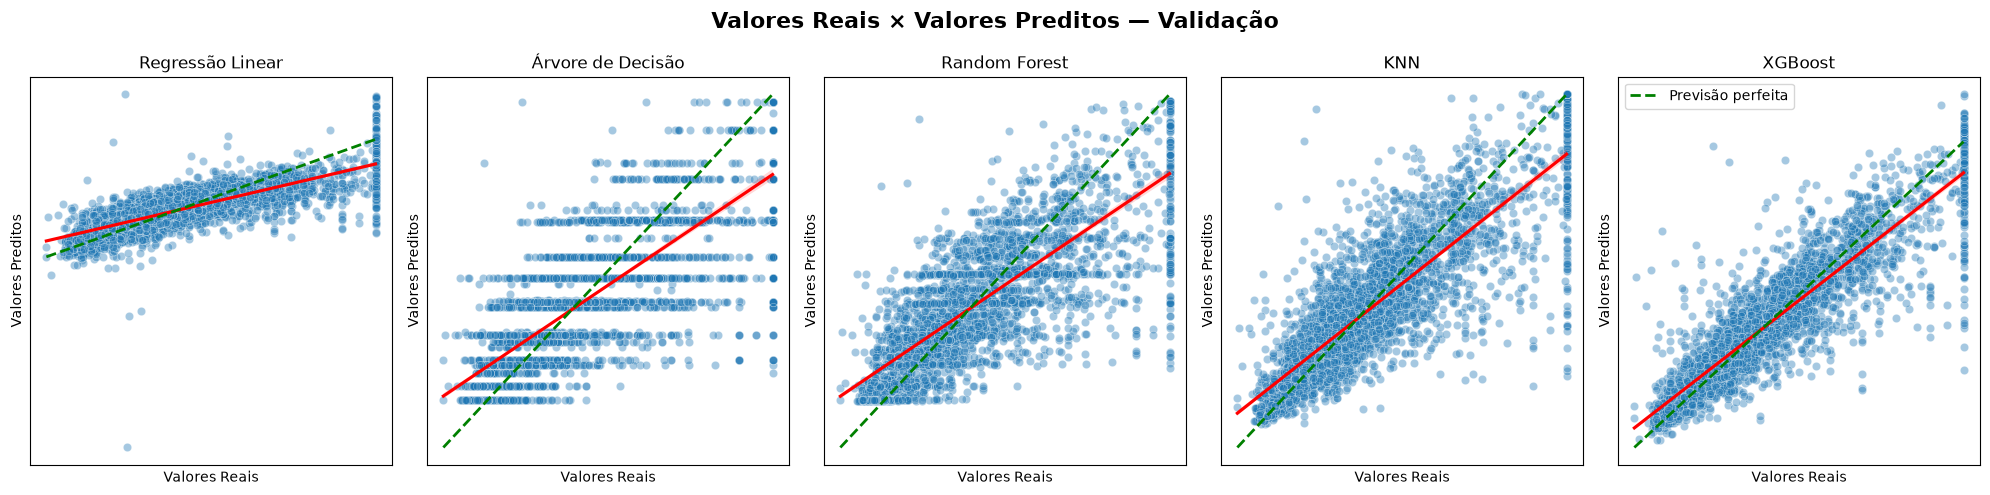

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (nome, modelo) in zip(axes, modelos_regressao.items()):
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_val)

    sns.scatterplot(x=y_val, y=pred, ax=ax, alpha=0.4)
    sns.regplot(x=y_val, y=pred, ax=ax, scatter=False, color="red")
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="green", linestyle="--", linewidth=2, label="Previsão perfeita")

    ax.set_title(nome)
    ax.set_xlabel("Valores Reais")
    ax.set_ylabel("Valores Preditos")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.2)


fig.suptitle("Valores Reais × Valores Preditos — Validação", fontsize=16, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## 10.2 Modelos com Feature Engineering

Neste segundo cenário, são adicionadas as variáveis `comodos_por_domicilio` e `quartos_por_comodo`.

Os mesmos algoritmos e o mesmo conjunto de validação são utilizados para verificar de forma consistente se as novas features contribuem para melhorar o desempenho dos modelos.

In [28]:
resultados_fe = []

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_treino_fe, y_treino)
    y_pred = modelo.predict(X_val_fe)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred)

    resultados_fe.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_fe_df = pd.DataFrame(resultados_fe).sort_values(by="MAE", ascending=True)
resultados_fe_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.829,31021.523,47706.857,0.177
3,KNN,0.721,40234.475,60912.261,0.220
2,Random Forest,0.644,48537.880,68831.690,0.278
0,Regressão Linear,0.633,49235.603,69850.750,0.287
1,Árvore de Decisão,0.617,50529.085,71385.804,0.287


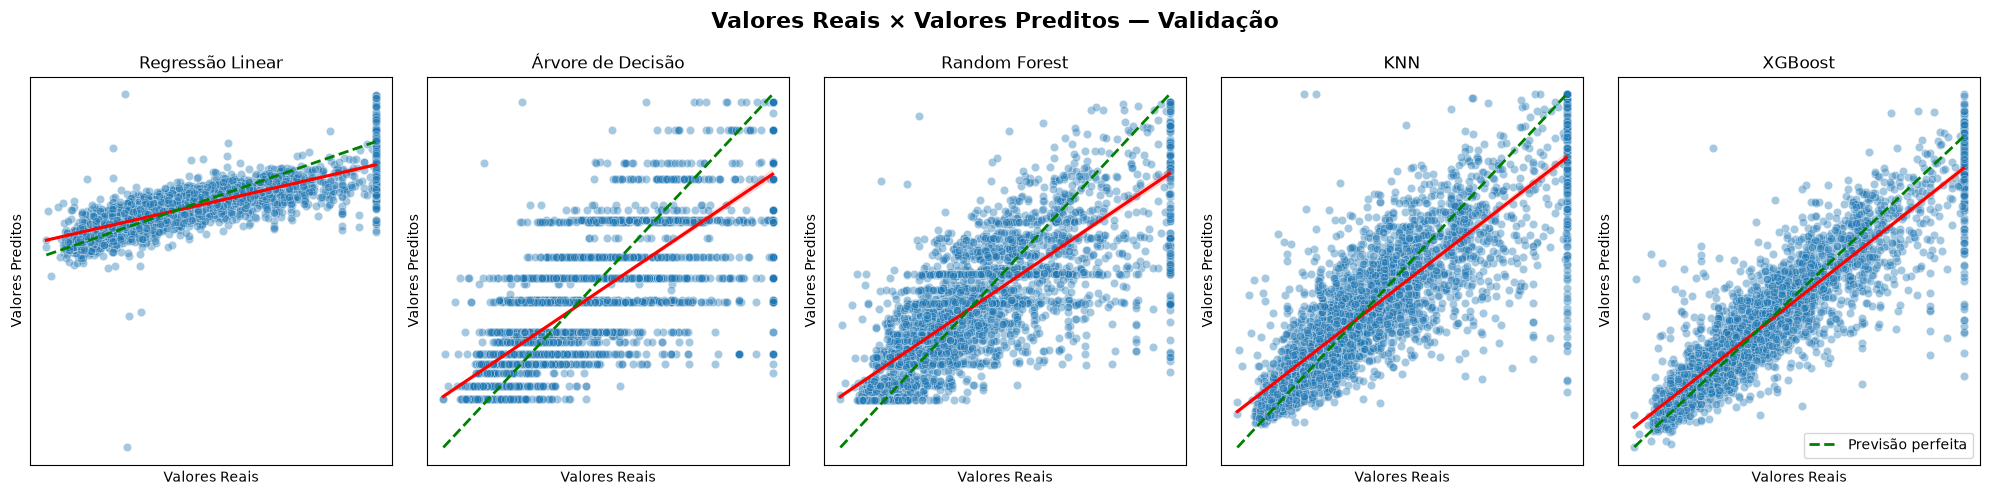

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (nome, modelo) in zip(axes, modelos_regressao.items()):
    modelo.fit(X_treino_fe, y_treino)
    pred = modelo.predict(X_val_fe)

    sns.scatterplot(x=y_val, y=pred, ax=ax, alpha=0.4)
    sns.regplot(x=y_val, y=pred, ax=ax, scatter=False, color="red")
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="green", linestyle="--", linewidth=2, label="Previsão perfeita")

    ax.set_title(nome)
    ax.set_xlabel("Valores Reais")
    ax.set_ylabel("Valores Preditos")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.2)

axes[-1].legend(loc="lower right")

fig.suptitle("Valores Reais × Valores Preditos — Validação", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## 10.3 Conclusão da Comparação

A inclusão das novas features apresentou impacto diferente entre os modelos, mas o principal ganho ocorreu no **XGBoost**, que já havia apresentado o melhor desempenho no cenário original.

Com Feature Engineering, o modelo apresentou melhora nas principais métricas, com aumento do R² e redução de MAE, RMSE e MAPE.

Dessa forma, o conjunto **com Feature Engineering será mantido nas próximas etapas de otimização, validação e construção do modelo final**.

# 11. Otimização de Hiperparâmetros com RandomizedSearchCV

Após a comparação inicial, os três modelos com melhor desempenho foram selecionados para otimização: **XGBoost, Random Forest e KNN**.

Nesta etapa é utilizado o `RandomizedSearchCV`, que testa diferentes combinações de hiperparâmetros por meio de Cross-Validation. Foram avaliadas **30 combinações por modelo com 5 folds**, utilizando o **MAE** como métrica principal de seleção.

Todos os experimentos utilizam o conjunto com Feature Engineering, definido anteriormente como cenário principal para as próximas etapas.

In [30]:
xgb_model = xgb.XGBRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
knn_model = KNeighborsRegressor()

In [31]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}
# KNN
param_dist_knn = {
    "n_neighbors": [5, 10, 15, 20],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "leaf_size": [20, 30, 40]
}

In [32]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

## 11.1 Busca pelas Melhores Configurações

O espaço de busca foi definido de acordo com as características de cada algoritmo, explorando parâmetros relacionados à complexidade, regularização, quantidade de estimadores e comportamento de aprendizagem.

Além das melhores configurações encontradas, também foi registrado o tempo necessário para otimizar cada modelo, permitindo observar o custo computacional do processo.

In [33]:
inicio = time.perf_counter()
random_xgb.fit(X_treino_fe, y_treino)
tempo_xgb = time.perf_counter() - inicio

inicio = time.perf_counter()
random_rf.fit(X_treino_fe, y_treino)
tempo_rf = time.perf_counter() - inicio

inicio = time.perf_counter()
random_knn.fit(X_treino_fe, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores Hiperparametros")
print(random_xgb.best_params_)
print("\nRandom Forest - melhores Hiperparametros")
print(random_rf.best_params_)
print("\nKNN - melhores Hiperparametros")
print(random_knn.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBoost - melhores Hiperparametros
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}

Random Forest - melhores Hiperparametros
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

KNN - melhores Hiperparametros
{'weights': 'distance', 'p': 1, 'n_neighbors': 10, 'leaf_size': 40}


In [34]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_val_fe)

    r2 = r2_score(y_val, pred)
    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mape = mean_absolute_percentage_error(y_val, pred)

    resultados.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_tunados = pd.DataFrame(resultados).sort_values(by="MAE", ascending=True)

print(f"Tempo XGBoost -> {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest -> {tempo_rf:.2f} segundos")
print(f"Tempo KNN -> {tempo_knn:.2f} segundos")

resultados_tunados.round(3)

Tempo XGBoost -> 34.49 segundos
Tempo Random Forest -> 212.74 segundos
Tempo KNN -> 12.32 segundos


,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Tunado,0.817,32446.675,49363.661,0.184
1,Random Forest Tunado,0.801,33755.436,51488.624,0.193
2,KNN Tunado,0.745,38501.112,58256.731,0.211


A otimização apresentou comportamentos diferentes entre os modelos.

O **Random Forest** apresentou uma melhora expressiva em relação à configuração inicial, alcançando aproximadamente **R² = 0,801** e **MAE = US$ 33,8 mil**. O **KNN** também apresentou evolução, reduzindo o erro e atingindo **R² = 0,745**.

Por outro lado, o **XGBoost Tunado** apresentou desempenho inferior ao XGBoost utilizado anteriormente, passando de aproximadamente **R² = 0,829 para 0,817** e aumentando o MAE de cerca de **US$ 31,0 mil para US$ 32,4 mil**.

Esse resultado demonstra que a otimização de hiperparâmetros não garante necessariamente melhoria no conjunto de validação. Por esse motivo, o XGBoost anterior será mantido como referência e novas estratégias de otimização serão avaliadas antes da escolha do modelo final.

# 12. Ensemble com Voting Regressor

Após a otimização dos principais modelos, é testada uma abordagem de ensemble utilizando o `VotingRegressor`.

O método combina as previsões de diferentes algoritmos e retorna uma média das estimativas, buscando aproveitar comportamentos complementares entre os modelos.

Neste experimento foram utilizados o **XGBoost** e o **Random Forest** otimizados.

In [35]:
modelo_xgb_tunado = random_xgb.best_estimator_
modelo_rf_tunado = random_rf.best_estimator_
modelo_knn_tunado = random_knn.best_estimator_

In [36]:
modelo_voting = VotingRegressor(
    estimators=[
        ("xgboost", modelo_xgb_tunado),
        ("random_forest", modelo_rf_tunado)
    ],
    n_jobs=-1
)

In [37]:
modelo_voting.fit(X_treino_fe, y_treino)
pred_voting = modelo_voting.predict(X_val_fe)

resultado_voting = {
    "Modelo": "Modelo Voting",
    "R²": r2_score(y_val, pred_voting),
    "MAE": mean_absolute_error(y_val, pred_voting),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_voting)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_voting)
}

resultado_voting_df = pd.DataFrame([resultado_voting])
resultado_voting_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,Modelo Voting,0.818,31980.611,49174.157,0.182



O Voting Regressor apresentou aproximadamente **R² = 0,818**, **MAE = US$ 32,0 mil** e **RMSE = US$ 49,2 mil**.

Apesar de apresentar desempenho competitivo, o ensemble não conseguiu superar o XGBoost utilizado anteriormente, indicando que a combinação das previsões não trouxe ganho suficiente para justificar sua escolha como modelo principal.

# 13. Ensemble com Stacking Regressor

Como segunda estratégia de ensemble, é utilizado o `StackingRegressor`, combinando as previsões de **XGBoost, Random Forest e KNN**.

Diferentemente do Voting, o Stacking utiliza as previsões dos modelos base como entrada para um segundo modelo, responsável por aprender como combiná-las. Neste experimento, uma Regressão Linear é utilizada como `final_estimator`.

In [38]:
modelo_stacking = StackingRegressor(
    estimators=[
        ("XGBoost", modelo_xgb_tunado),
        ("Random_forest", modelo_rf_tunado),
        ("KNN", modelo_knn_tunado)
    ],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

In [39]:
modelo_stacking.fit(X_treino_fe, y_treino)
pred_stacking = modelo_stacking.predict(X_val_fe)

resultado_stacking = {
    "Modelo": "Modelo Stacking",
    "R²": r2_score(y_val, pred_stacking),
    "MAE": mean_absolute_error(y_val, pred_stacking),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_stacking)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_stacking)
}

resultado_stacking_df = pd.DataFrame([resultado_stacking])
resultado_stacking_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,Modelo Stacking,0.822,31635.354,48725.783,0.177



O Stacking apresentou desempenho superior ao Voting, alcançando aproximadamente **R² = 0,822**, **MAE = US$ 31,6 mil** e **RMSE = US$ 48,7 mil**.

O resultado mostra que a combinação aprendida entre os modelos conseguiu capturar informações complementares, porém ainda não superou o desempenho do XGBoost utilizado como referência.

# 14. Comparação Geral dos Modelos

Após os experimentos com modelos individuais, otimização de hiperparâmetros e técnicas de ensemble, todos os resultados são consolidados em uma única comparação.

O objetivo é avaliar qual abordagem apresenta o melhor equilíbrio entre capacidade explicativa e erro de previsão no conjunto de validação.

In [40]:
resultado_final = pd.concat([resultados_fe_df, resultados_tunados, resultado_voting_df, resultado_stacking_df])
resultado_final = resultado_final.sort_values(by="MAE", ascending=True)
resultado_final.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.829,31021.523,47706.857,0.177
0,Modelo Stacking,0.822,31635.354,48725.783,0.177
0,Modelo Voting,0.818,31980.611,49174.157,0.182
0,XGBoost Tunado,0.817,32446.675,49363.661,0.184
1,Random Forest Tunado,0.801,33755.436,51488.624,0.193
2,KNN Tunado,0.745,38501.112,58256.731,0.211
3,KNN,0.721,40234.475,60912.261,0.220
2,Random Forest,0.644,48537.880,68831.690,0.278
0,Regressão Linear,0.633,49235.603,69850.750,0.287
1,Árvore de Decisão,0.617,50529.085,71385.804,0.287


O **XGBoost com Feature Engineering e configuração inicial** permaneceu como o modelo de melhor desempenho, alcançando aproximadamente:

- **R²:** 0,829;
- **MAE:** US$ 31,0 mil;
- **RMSE:** US$ 47,7 mil;
- **MAPE:** 17,7%.

O Stacking apresentou resultado próximo, mas não conseguiu superar o XGBoost. O mesmo ocorreu com Voting e com as versões otimizadas pelo `RandomizedSearchCV`.

Esse resultado reforça que maior complexidade ou otimização de hiperparâmetros não garantem automaticamente melhor desempenho. Por esse motivo, o **XGBoost permanece como principal candidato para as próximas etapas de otimização e validação**.

# 15. Otimização do XGBoost com Optuna

Após os experimentos anteriores, o XGBoost permaneceu como o modelo com melhor desempenho. Por esse motivo, foi realizada uma nova etapa de otimização utilizando **Optuna**.

Diferentemente de uma busca baseada apenas em combinações pré-definidas, o Optuna utiliza uma estratégia adaptativa para explorar o espaço de hiperparâmetros e concentrar as próximas tentativas em regiões mais promissoras.

A otimização utiliza **K-Fold Cross-Validation com 5 folds** e o **MAE** como métrica objetivo.

In [83]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):

    params = {
    "n_estimators": trial.suggest_int("n_estimators", 300, 900),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.07, log=True),
    "max_depth": trial.suggest_int("max_depth", 2, 5),
    "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
    "subsample": trial.suggest_float("subsample", 0.60, 0.90),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 0.90),
    "gamma": trial.suggest_float("gamma", 0.10, 3.0),
    "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
    "reg_lambda": trial.suggest_float("reg_lambda", 3.0, 30.0)
}

    modelo = xgb.XGBRegressor(**params, objective="reg:squarederror", random_state=42, n_jobs=1)

    score = cross_val_score(modelo, X_treino_fe, y_treino, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1).mean()

    return -score

In [84]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb.optimize(
    objective_xgb,
    n_trials=30
)

[I 2026-09-09 13:28:32,550] A new study created in memory with name: no-name-55764f80-d5a4-422e-babd-cd6eaf138b56
[I 2026-09-09 13:28:43,829] Trial 0 finished with value: 33291.20853958396 and parameters: {'n_estimators': 525, 'learning_rate': 0.06359848890377333, 'max_depth': 4, 'min_child_weight': 14, 'subsample': 0.6468055921327309, 'colsample_bytree': 0.6467983561008608, 'gamma': 0.2684424752877784, 'reg_alpha': 4.330880728874676, 'reg_lambda': 19.230105317066638}. Best is trial 0 with value: 33291.20853958396.
[I 2026-09-09 13:28:50,199] Trial 1 finished with value: 35287.083146885925 and parameters: {'n_estimators': 725, 'learning_rate': 0.010408686202776001, 'max_depth': 5, 'min_child_weight': 18, 'subsample': 0.6637017332034828, 'colsample_bytree': 0.6545474901621302, 'gamma': 0.631873078574958, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 17.168423654070423}. Best is trial 0 with value: 33291.20853958396.
[I 2026-09-09 13:28:54,331] Trial 2 finished with value: 35970.4513423

In [85]:
print(f"Melhor MAE -> {study_xgb.best_value:.4f}")

print("\nMelhores Hiperparâmetros:")
print(study_xgb.best_params)

Melhor MAE -> 32837.5318

Melhores Hiperparâmetros:
{'n_estimators': 619, 'learning_rate': 0.06483493657980093, 'max_depth': 4, 'min_child_weight': 13, 'subsample': 0.6474188052829788, 'colsample_bytree': 0.7289420519084958, 'gamma': 0.8889780145764901, 'reg_alpha': 2.832525118100155, 'reg_lambda': 22.833194033441846}


In [86]:
modelo_xgb_optuna = xgb.XGBRegressor(**study_xgb.best_params, objective="reg:squarederror", random_state=42, n_jobs=-1)

modelo_xgb_optuna.fit(X_treino_fe, y_treino)

pred_optuna = modelo_xgb_optuna.predict(X_val_fe)

In [87]:
resultado_optuna = {
    "Modelo": "XGBoost Optuna",
    "R²": r2_score(y_val, pred_optuna),
    "MAE": mean_absolute_error(y_val, pred_optuna),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_optuna)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_optuna)
}

resultado_optuna_df = pd.DataFrame([resultado_optuna])
resultado_optuna_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna,0.82,32159.613,48962.647,0.182


Neste primeiro estudo foram realizadas **30 tentativas de otimização**, utilizando um espaço de busca mais conservador para reduzir a complexidade do XGBoost e controlar o overfitting.

Após treinar o modelo com os hiperparâmetros selecionados e avaliá-lo no conjunto de validação, foram obtidos aproximadamente:

- **R²:** 0,820;
- **MAE:** US$ 32,2 mil;
- **RMSE:** US$ 49,0 mil;
- **MAPE:** 18,2%.

O desempenho preditivo apresentou uma pequena redução em relação ao experimento anterior, comportamento esperado diante do aumento da regularização. O objetivo desta configuração é avaliar se essa perda de desempenho é compensada por uma melhor capacidade de generalização e menor diferença entre treino e validação.

In [88]:
fig1 = viz.plot_optimization_history(study_xgb, target_name="MAE")
fig1.show()

fig2 = viz.plot_param_importances(study_xgb, target_name="MAE")
fig2.show()

O histórico das tentativas mostra que o Optuna encontrou configurações progressivamente melhores ao longo do estudo, embora os ganhos tenham se tornado menores nas últimas iterações.

Neste experimento, `subsample` apresentou a maior influência sobre o resultado da otimização, respondendo por aproximadamente **42% da importância observada no estudo**. Em seguida aparecem `learning_rate`, `n_estimators`, `min_child_weight` e `reg_alpha`.

Esse comportamento é coerente com o objetivo desta nova busca, pois `subsample` controla a quantidade de observações utilizadas por cada árvore e atua diretamente na redução da variância e do overfitting.

É importante destacar que essa importância representa o impacto dos **hiperparâmetros dentro deste estudo do Optuna**, e não a importância das features utilizadas pelo modelo.

A decisão sobre manter essa configuração não será baseada apenas no MAE de validação, mas também na estabilidade obtida em Cross-Validation e no comportamento da Learning Curve.

## 15.3 Ampliação da Otimização — 100 Trials

Após o primeiro experimento, a busca com Optuna foi ampliada de **30 para 100 trials**, mantendo o mesmo espaço de hiperparâmetros, a mesma estratégia de amostragem e a avaliação por MAE com K-Fold Cross-Validation.

O objetivo é verificar se um número maior de tentativas permite encontrar uma configuração mais eficiente para o XGBoost e se o ganho observado durante a otimização também se mantém no conjunto de validação.

In [134]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb_100 = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb_100.optimize(
    objective_xgb,
    n_trials=100
)

[I 2026-09-09 14:06:28,940] A new study created in memory with name: no-name-61dc5e56-85c4-43e6-b75e-67a561c862ab


[I 2026-09-09 14:06:43,194] Trial 0 finished with value: 33291.20853958396 and parameters: {'n_estimators': 525, 'learning_rate': 0.06359848890377333, 'max_depth': 4, 'min_child_weight': 14, 'subsample': 0.6468055921327309, 'colsample_bytree': 0.6467983561008608, 'gamma': 0.2684424752877784, 'reg_alpha': 4.330880728874676, 'reg_lambda': 19.230105317066638}. Best is trial 0 with value: 33291.20853958396.
[I 2026-09-09 14:06:48,716] Trial 1 finished with value: 35287.083146885925 and parameters: {'n_estimators': 725, 'learning_rate': 0.010408686202776001, 'max_depth': 5, 'min_child_weight': 18, 'subsample': 0.6637017332034828, 'colsample_bytree': 0.6545474901621302, 'gamma': 0.631873078574958, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 17.168423654070423}. Best is trial 0 with value: 33291.20853958396.
[I 2026-09-09 14:06:53,468] Trial 2 finished with value: 35970.45134232108 and parameters: {'n_estimators': 559, 'learning_rate': 0.01762451503554604, 'max_depth': 4, 'min_child_weight

In [135]:
print(f"Melhor MAE -> {study_xgb_100.best_value:.4f}")

print("\nMelhores Hiperparâmetros")
print(study_xgb_100.best_params)

Melhor MAE -> 31529.5083

Melhores Hiperparâmetros
{'n_estimators': 868, 'learning_rate': 0.06737798699001653, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.6351624125930612, 'colsample_bytree': 0.6779840859874089, 'gamma': 0.29316651276835226, 'reg_alpha': 2.021010989076048, 'reg_lambda': 20.185547586693403}


In [136]:
fig1_100 = viz.plot_optimization_history(study_xgb_100, target_name="MAE")
fig1_100.show()

fig2_100 = viz.plot_param_importances(study_xgb_100, target_name="MAE")
fig2_100.show()

In [137]:
modelo_xgb_optuna_100 = xgb.XGBRegressor(**study_xgb_100.best_params, objective="reg:absoluteerror", random_state=42, n_jobs=-1)

modelo_xgb_optuna_100.fit(X_treino_fe, y_treino)

pred_optuna_100 = modelo_xgb_optuna_100.predict(X_val_fe)

In [138]:
resultado_optuna_100 = {
    "Modelo": "XGBoost Optuna - 100",
    "R²": r2_score(y_val, pred_optuna_100),
    "MAE": mean_absolute_error(y_val, pred_optuna_100),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_optuna_100)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_optuna_100)
}

resultado_optuna_df_100 = pd.DataFrame([resultado_optuna_100])
resultado_optuna_df_100.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna - 100,0.819,30638.665,49028.366,0.166


Com a ampliação da busca para **100 trials**, o Optuna continuou refinando o espaço de hiperparâmetros e encontrou configurações mais competitivas ao longo das tentativas.

O histórico mostra uma redução gradual do melhor MAE, com ganhos cada vez menores nas etapas finais, indicando aproximação de uma região mais estável da busca.

Neste estudo, `n_estimators` apresentou a maior influência sobre o desempenho da otimização, seguido por `learning_rate`, `min_child_weight` e `reg_lambda`. Isso sugere que o equilíbrio entre quantidade de árvores, taxa de aprendizagem e regularização foi determinante para o comportamento do modelo.

# 16. Comparação Final dos Experimentos

Após os testes com modelos individuais, Feature Engineering, RandomizedSearchCV, ensembles e diferentes estratégias de otimização com Optuna, os principais resultados são consolidados para uma comparação final.

O **MAE** é utilizado como métrica principal de decisão, por representar diretamente o erro absoluto médio das previsões. R², RMSE e MAPE são utilizados de forma complementar para avaliar capacidade explicativa, sensibilidade a erros elevados e erro percentual.

A comparação busca identificar o modelo com melhor equilíbrio entre **desempenho preditivo, regularização e capacidade de generalização** antes das etapas finais de validação.

In [139]:
resultados = pd.concat([resultado_final, resultado_optuna_df, resultado_optuna_df_100])
resultados = resultados.sort_values(by="MAE", ascending=True)
resultados.head(5).round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna - 100,0.819,30638.665,49028.366,0.166
4,XGBoost,0.829,31021.523,47706.857,0.177
0,Modelo Stacking,0.822,31635.354,48725.783,0.177
0,Modelo Voting,0.818,31980.611,49174.157,0.182
0,XGBoost Optuna,0.820,32159.613,48962.647,0.182


C:\Users\Unisalesiano\AppData\Local\Temp\ipykernel_18556\2041426203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resultados, x="MAE", y="Modelo", palette="coolwarm")


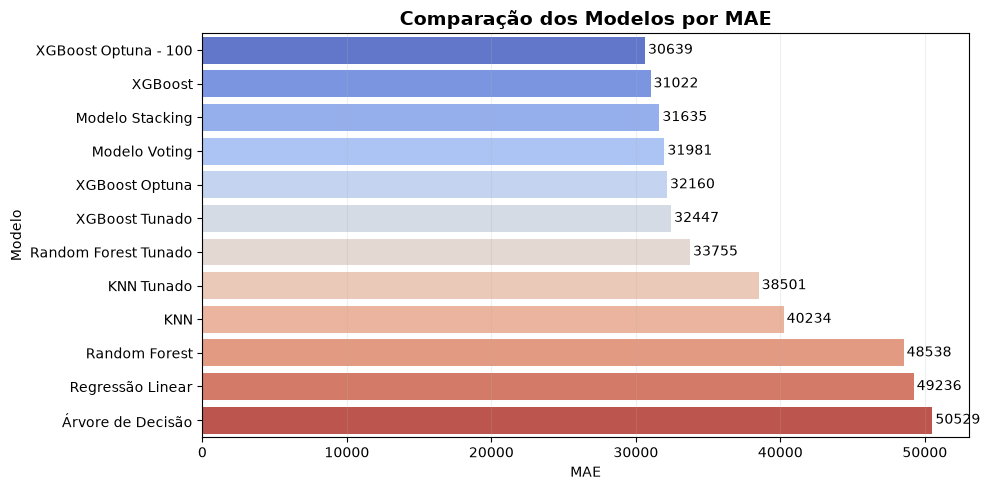

In [140]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=resultados, x="MAE", y="Modelo", palette="coolwarm")

for i, valor in enumerate(resultados["MAE"]):
    ax.text(valor + 200, i, f"{valor:.0f}", va="center")

plt.title("Comparação dos Modelos por MAE", fontsize=14, fontweight="bold")
plt.xlabel("MAE")
plt.ylabel("Modelo")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

O **XGBoost otimizado com 100 trials do Optuna** apresentou o menor MAE entre os experimentos, aproximadamente **US$ 30,6 mil**, além do menor MAPE, próximo de **16,6%**.

Embora o XGBoost anterior apresente R² e RMSE ligeiramente melhores, a configuração encontrada pelo Optuna com 100 trials foi construída a partir de um espaço de busca mais regularizado e apresentou melhor desempenho nas métricas definidas como prioritárias para o problema.

Dessa forma, o **XGBoost Optuna — 100 trials** será utilizado como principal candidato nas próximas análises de estabilidade e generalização.

A decisão final será confirmada por meio de **Cross-Validation, Learning Curve e avaliação no conjunto de teste**, evitando selecionar o modelo apenas pelo desempenho observado em uma única divisão de validação.

# 17. Validação Cruzada do Pipeline Final

Após a seleção do XGBoost otimizado, a validação cruzada é realizada sobre o **pipeline completo**, incluindo pré-processamento e modelo.

Para evitar data leakage, os dados utilizados na Cross-Validation são reconstruídos antes das transformações. Dessa forma, em cada fold o preprocessador aprende imputação, escala e codificação categórica exclusivamente com os dados de treino daquele fold.

A avaliação utiliza **KFold com 5 divisões** e considera as métricas R², MAE, RMSE e MAPE.

In [141]:
pipeline_final = Pipeline([
    ("preprocessador", preprocessador_fe),
    ("modelo", modelo_xgb_optuna_100)
])

In [142]:
X_treino_fe_cv = dados.loc[y_treino.index].drop(columns=["valor_media_imovel", "faixa_preco"], errors="ignore")
X_treino_fe_cv = criar_colunas(X_treino_fe_cv)

In [143]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

metricas = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error", "neg_mean_absolute_percentage_error"]

cv_resultados = cross_validate(pipeline_final, X_treino_fe_cv, y_treino, cv=cv, scoring=metricas, n_jobs=-1)

In [144]:
cv_df = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE", "MAPE (%)"],
    "Média": [
        cv_resultados["test_r2"].mean(),
        -cv_resultados["test_neg_mean_absolute_error"].mean(),
        -cv_resultados["test_neg_root_mean_squared_error"].mean(),
        -cv_resultados["test_neg_mean_absolute_percentage_error"].mean() * 100
    ],
    "Desvio Padrão": [
        cv_resultados["test_r2"].std(),
        cv_resultados["test_neg_mean_absolute_error"].std(),
        cv_resultados["test_neg_root_mean_squared_error"].std(),
        cv_resultados["test_neg_mean_absolute_percentage_error"].std() * 100
    ]
})

cv_df.round(3)

,Métrica,Média,Desvio Padrão
0,R²,0.827,0.009
1,MAE,31256.152,573.249
2,RMSE,47998.450,811.273
3,MAPE (%),16.620,0.204


O pipeline apresentou desempenho estável entre os cinco folds, com os seguintes resultados médios:

- **R²:** 0,827 ± 0,009;
- **MAE:** US$ 31,3 mil ± US$ 573;
- **RMSE:** US$ 48,0 mil ± US$ 811;
- **MAPE:** 16,62% ± 0,20%.

Os baixos desvios padrão indicam pouca variação entre os folds, sugerindo que o modelo mantém comportamento consistente em diferentes subconjuntos dos dados.

Mesmo com uma pequena redução no desempenho médio em relação a alguns experimentos anteriores, a estabilidade observada reforça que o pipeline regularizado apresenta boa capacidade de generalização.

Essa avaliação é mais rigorosa, pois todo o pré-processamento é reajustado dentro de cada fold, fornecendo uma estimativa mais confiável do desempenho fora da amostra.

# 18. Análise de Overfitting com Learning Curve

Após avaliar a estabilidade do pipeline por Cross-Validation, é analisado o comportamento do erro conforme a quantidade de dados de treinamento aumenta.

A Learning Curve permite comparar o desempenho em treino e validação, ajudando a identificar sinais de overfitting, underfitting e o potencial benefício da inclusão de mais dados.

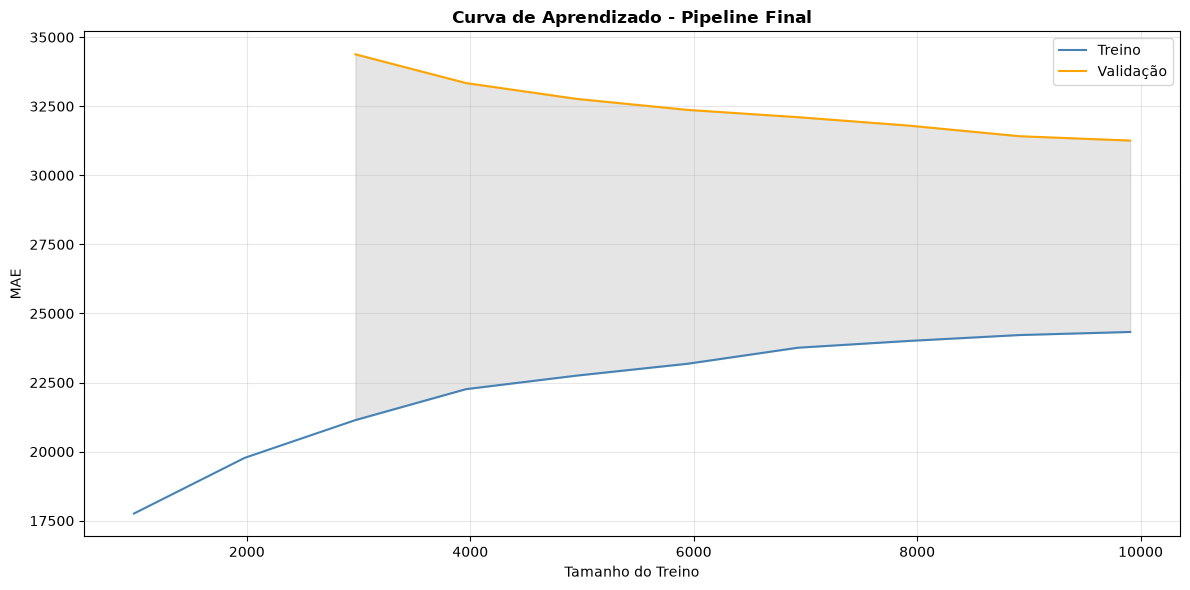

In [145]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, validation_scores = learning_curve(estimator=pipeline_final, X=X_treino_fe_cv, y=y_treino, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10), scoring="neg_mean_absolute_error", n_jobs=-1)

train_mean = -train_scores.mean(axis=1)
val_mean = -validation_scores.mean(axis=1)

plt.figure(figsize=(12, 6))

plt.plot(train_sizes, train_mean, label="Treino", color="steelblue")
plt.plot(train_sizes, val_mean, label="Validação", color="orange")
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color="gray")

plt.title("Curva de Aprendizado - Pipeline Final", fontweight="bold")
plt.xlabel("Tamanho do Treino")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A curva de aprendizado apresenta um comportamento consistente: conforme a quantidade de dados aumenta, o erro de treino cresce enquanto o erro de validação diminui, indicando aproximação gradual entre as duas curvas.

No maior conjunto utilizado, foram obtidos:

- **MAE de treino:** aproximadamente US$ 24,3 mil;
- **MAE de validação:** aproximadamente US$ 31,3 mil;
- **gap treino-validação:** aproximadamente US$ 6,9 mil.

O gap observado é significativamente menor do que nos experimentos anteriores, indicando que o aumento da regularização reduziu o overfitting e aproximou o comportamento do modelo entre treino e validação.

Além disso, o erro de validação continua apresentando tendência de queda com o aumento da quantidade de dados, enquanto o erro de treino começa a se estabilizar.

Quando analisado em conjunto com a baixa variabilidade observada na Cross-Validation, o resultado indica um modelo mais equilibrado entre capacidade de ajuste e generalização.

Dessa forma, o nível de overfitting observado é considerado **baixo a moderado e aceitável**, permitindo prosseguir com maior confiança para a avaliação final no conjunto de teste.

In [146]:
gap_final = val_mean[-1] - train_mean[-1]

print(f"MAE - Treino: {train_mean[-1]:.4f}")
print(f"MAE - Validação: {val_mean[-1]:.4f}")
print(f"GAP Final -> {gap_final:.4f}")

MAE - Treino: 24330.9643
MAE - Validação: 31258.4599
GAP Final -> 6927.4956


# 19. Avaliação Final no Conjunto de Teste

Após a seleção do modelo e as análises de estabilidade e overfitting, o conjunto de teste é utilizado para realizar a avaliação final.

Esse conjunto permaneceu isolado durante as etapas de treinamento, comparação e otimização, permitindo estimar de forma mais confiável o desempenho do modelo em dados não utilizados durante seu desenvolvimento.

In [147]:
pred_final = modelo_xgb_optuna_100.predict(X_teste_fe)

resultados_teste = {
    "R²": r2_score(y_teste, pred_final),
    "MAE": mean_absolute_error(y_teste, pred_final),
    "RMSE": np.sqrt(mean_squared_error(y_teste, pred_final)),
    "MAPE": mean_absolute_percentage_error(y_teste, pred_final)
}

resultados_df_teste = pd.DataFrame([resultados_teste])
resultados_df_teste.round(3)

,R²,MAE,RMSE,MAPE
0,0.824,30596.459,48129.023,0.159


No conjunto de teste, o modelo apresentou:

- **R²:** 0,824;
- **MAE:** aproximadamente US$ 30,6 mil;
- **RMSE:** aproximadamente US$ 48,1 mil;
- **MAPE:** 15,9%.

Os resultados permanecem próximos aos observados durante a Cross-Validation, que apresentou R² médio de 0,827 e MAE próximo de US$ 31,3 mil. Essa proximidade indica boa consistência entre validação e teste.

O desempenho final também mostra que aproximadamente **82,4% da variabilidade do valor dos imóveis é explicada pelo modelo**, enquanto o erro absoluto médio permanece em torno de US$ 30,6 mil.

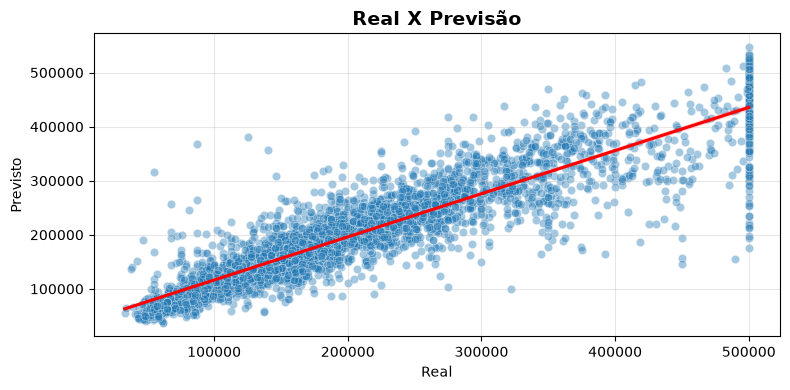

In [148]:
plt.figure(figsize=(8,4))

sns.scatterplot(x=y_teste, y=pred_final, alpha=0.4)
sns.regplot(x=y_teste, y=pred_final, scatter=False, color="red")

plt.title("Real X Previsão", fontsize=14, fontweight="bold")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

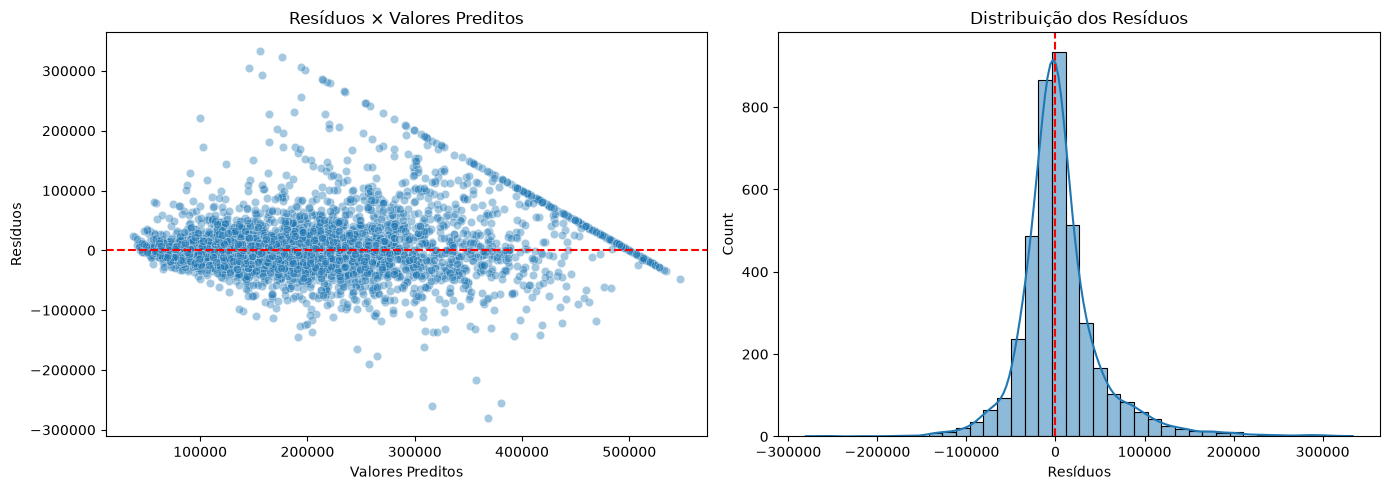

In [149]:
residuos = y_teste - pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=pred_final, y=residuos, alpha=0.4, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Resíduos × Valores Preditos")
axes[0].set_xlabel("Valores Preditos")
axes[0].set_ylabel("Resíduos")

sns.histplot(residuos, bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduos")

plt.tight_layout()
plt.show()

Os resíduos permanecem concentrados próximos de zero, indicando que grande parte das previsões apresenta erros relativamente equilibrados entre superestimações e subestimações.

Entretanto, observa-se aumento da dispersão em algumas faixas de valor e a presença de erros mais elevados nos imóveis de maior preço. O padrão também é influenciado pelo limite superior existente na variável alvo, próximo de **US$ 500 mil**.

De forma geral, o comportamento dos resíduos e a proximidade entre os resultados de Cross-Validation e teste reforçam que o modelo apresenta boa capacidade de generalização, embora ainda existam limitações nas faixas de maior valorização imobiliária.

# 20. Importância das Features do Modelo Final

Após avaliar o desempenho preditivo, é analisada a importância das variáveis utilizadas pelo XGBoost.

A Feature Importance fornece uma medida relativa de quanto cada feature contribuiu para as decisões realizadas pelas árvores do modelo, ajudando a identificar quais características tiveram maior participação na construção das previsões.

Essa análise deve ser interpretada como importância para o modelo, e não como relação causal ou indicação da direção do efeito sobre o preço.

In [150]:
importance_xgb = pd.DataFrame({
    "feature": X_teste_fe.columns,
    "importance": modelo_xgb_optuna_100.feature_importances_
})

importance_xgb = importance_xgb.sort_values(by="importance", ascending=False)
print(importance_xgb)

                               feature  importance
8          proximidade_oceano_interior    0.411043
5                          renda_media    0.197058
9   proximidade_oceano_menos_1h_oceano    0.071165
10     proximidade_oceano_proximo_baia    0.067913
11   proximidade_oceano_proximo_oceano    0.066955
12                            latitude    0.037352
13                           longitude    0.029000
7                   quartos_por_comodo    0.027140
6                comodos_por_domicilio    0.024665
0                idade_mediana_imoveis    0.018892
3                            populacao    0.014731
1                        total_comodos    0.011605
2                        total_quartos    0.011251
4                           domicilios    0.011231


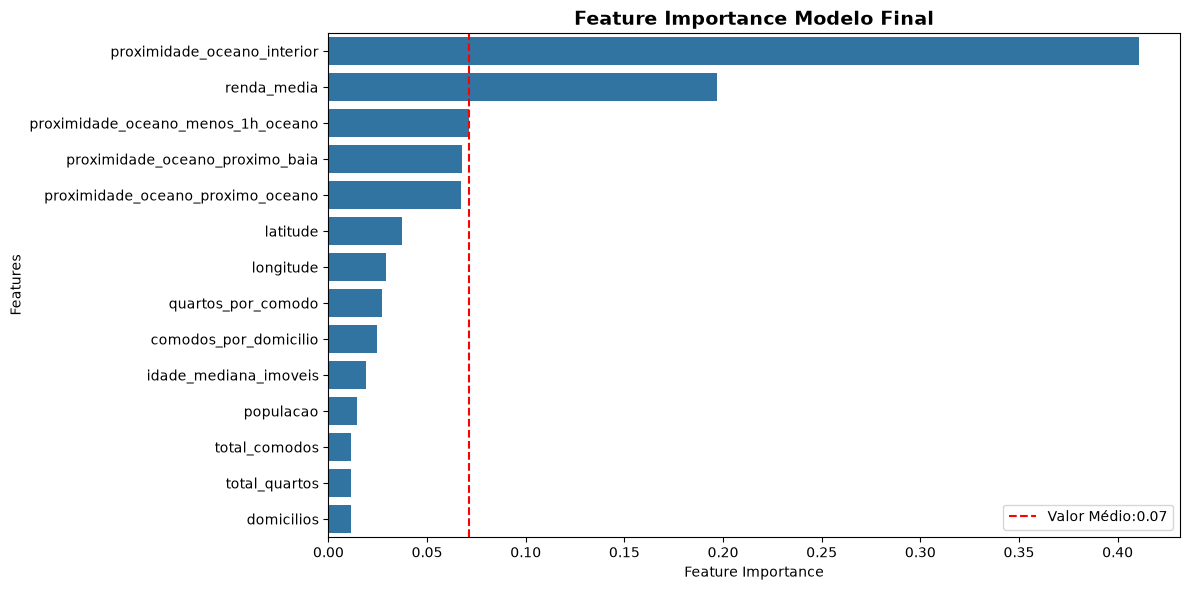

In [151]:
valor_medio = importance_xgb["importance"].mean()

plt.figure(figsize=(12,6))

sns.barplot(data=importance_xgb, x="importance", y="feature")
plt.axvline(importance_xgb["importance"].mean(), color="red", label=f"Valor Médio:{valor_medio:.2f}", linestyle='--')

plt.title("Feature Importance Modelo Final", fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.legend()
plt.tight_layout()
plt.show()

Os resultados reforçam os principais padrões identificados durante a análise exploratória.

A variável `proximidade_oceano_interior` apresentou a maior importância individual, seguida por `renda_media`. Outras categorias relacionadas à proximidade do oceano também aparecem entre as variáveis mais relevantes, mostrando que o **perfil geográfico possui forte participação nas decisões do modelo**.

A `renda_media` permanece como o principal fator econômico, confirmando sua forte relação com o valor dos imóveis observada anteriormente.

As variáveis `latitude` e `longitude` apresentam importância individual menor, mas complementam as informações de `proximidade_oceano` e ajudam o modelo a capturar padrões espaciais mais específicos.

As features criadas durante o Feature Engineering, `quartos_por_comodo` e `comodos_por_domicilio`, também permanecem entre as variáveis utilizadas pelo modelo, indicando contribuição adicional para as previsões, ainda que com importância inferior às características geográficas e econômicas.

> Como `proximidade_oceano` foi transformada por One-Hot Encoding, sua importância está distribuída entre várias features. Portanto, o impacto total da informação geográfica é maior do que a análise isolada de apenas uma categoria sugere.

# 21. Interpretabilidade do Modelo com SHAP

Após avaliar o desempenho e a importância das features, é utilizada a técnica **SHAP (SHapley Additive exPlanations)** para compreender com maior profundidade como o XGBoost constrói suas previsões.

Diferentemente da Feature Importance tradicional, o SHAP permite analisar não apenas quais variáveis são relevantes, mas também **a magnitude e a direção do impacto de cada feature sobre as previsões**.

As explicações são calculadas sobre o conjunto de teste já transformado pelo mesmo pré-processamento utilizado no modelo.

In [152]:
explainer = shap.TreeExplainer(modelo_xgb_optuna_100)

shap_values = explainer.shap_values(X_teste_fe)

print(f"Shape X_teste: {X_teste_fe.shape}")
print(f"Shape SHAP: {np.asarray(shap_values).shape}")

Shape X_teste: (4128, 14)
Shape SHAP: (4128, 14)


## 21.1 Importância Global das Variáveis

A importância global baseada na média dos valores absolutos de SHAP mostra que `renda_media`, `longitude` e `latitude` estão entre as variáveis com maior impacto médio nas previsões.

A variável `proximidade_oceano_interior` também aparece entre as mais relevantes, reforçando a forte influência da localização identificada durante a análise exploratória.

Esse resultado complementa a Feature Importance do XGBoost, mas fornece uma interpretação mais direta do impacto médio de cada variável sobre a saída do modelo.

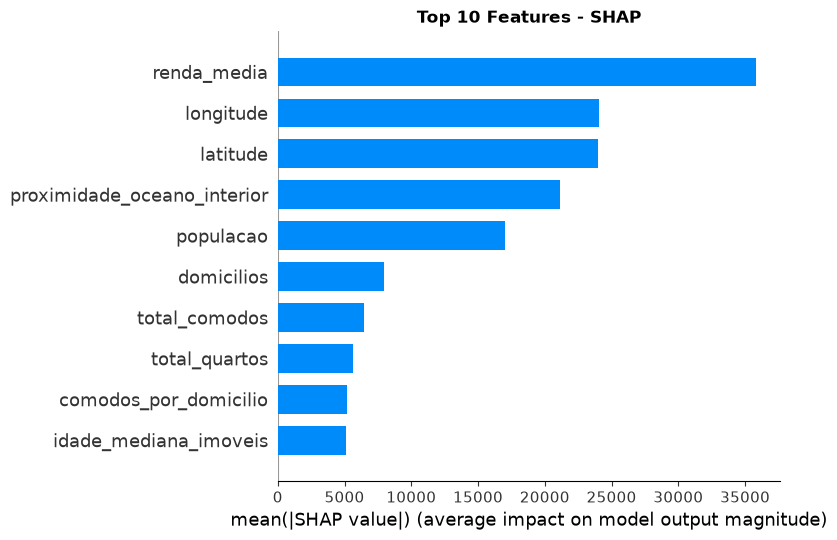

In [153]:
shap.summary_plot(
    shap_values,
    X_teste_fe,
    max_display=10,
    plot_type="bar",
    show=False
)

plt.title("Top 10 Features - SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

## 21.2 Direção e Magnitude dos Impactos

O summary plot permite observar não apenas a importância das variáveis, mas também **como valores altos e baixos influenciam as previsões**.

A `renda_media` apresenta um padrão claro: valores mais elevados tendem a aumentar significativamente o valor previsto dos imóveis, enquanto valores menores exercem impacto negativo.

As variáveis `longitude` e `latitude` apresentam comportamento mais complexo, evidenciando que a influência geográfica não é linear e depende da posição da região.

Para `proximidade_oceano_interior`, pertencer ao interior tende a reduzir o valor previsto, comportamento consistente com as diferenças observadas anteriormente entre regiões costeiras e áreas do interior.

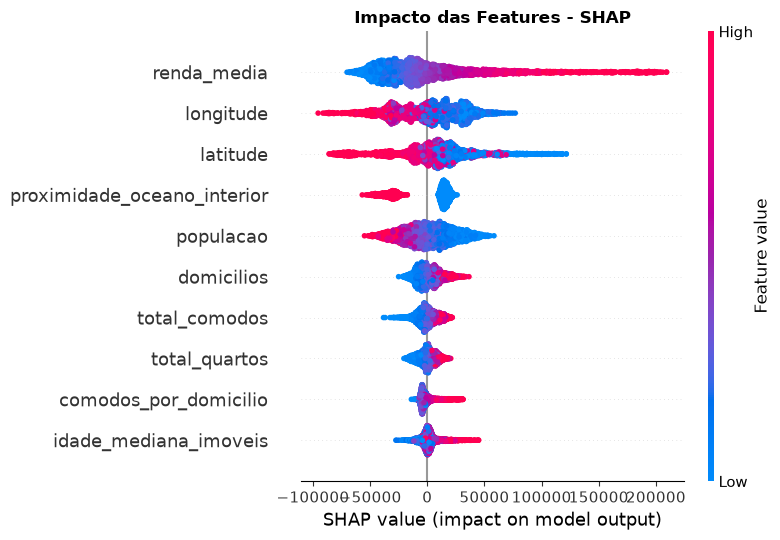

In [154]:
shap.summary_plot(
    shap_values,
    X_teste_fe,
    max_display=10,
    show=False
)

plt.title("Impacto das Features - SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

## 21.3 Dependência da Renda Média

O dependence plot evidencia uma relação não linear entre `renda_media` e sua contribuição para as previsões.

Conforme a renda aumenta, o impacto SHAP cresce de forma consistente, indicando que regiões economicamente mais favorecidas tendem a elevar significativamente o valor previsto dos imóveis.

Nas faixas mais altas de renda, o crescimento do impacto começa a apresentar sinais de estabilização, indicando que o efeito da variável não aumenta indefinidamente na mesma proporção.

A dispersão vertical também mostra que o impacto da renda pode variar de acordo com outras características da região, evidenciando interações capturadas pelo XGBoost.

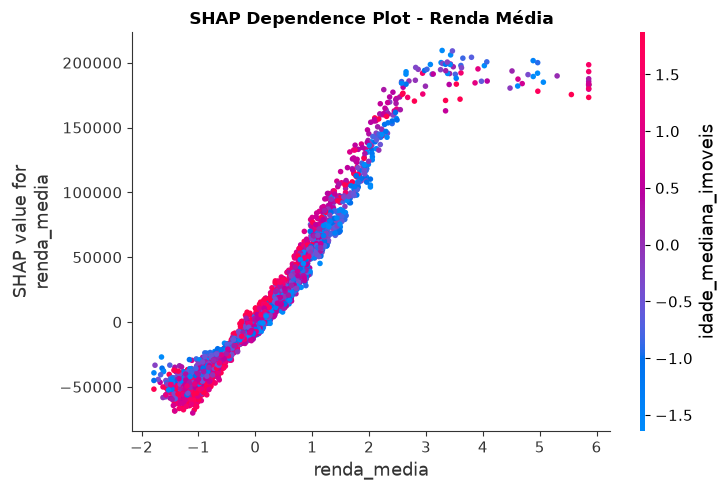

In [155]:
feature_dependence = "renda_media"

shap.dependence_plot(
    feature_dependence,
    shap_values,
    X_teste_fe,
    show=False
)
plt.title("SHAP Dependence Plot - Renda Média", fontweight="bold")
plt.tight_layout()
plt.show()


## 21.4 Explicação Individual de uma Previsão

Além da interpretação global, o SHAP permite explicar uma previsão específica.

O gráfico Waterfall parte de um valor médio esperado pelo modelo e mostra quanto cada variável contribuiu positiva ou negativamente até chegar à previsão final daquele registro.

Valor Real -> 176600.00
Valor Previsto -> 141990.58


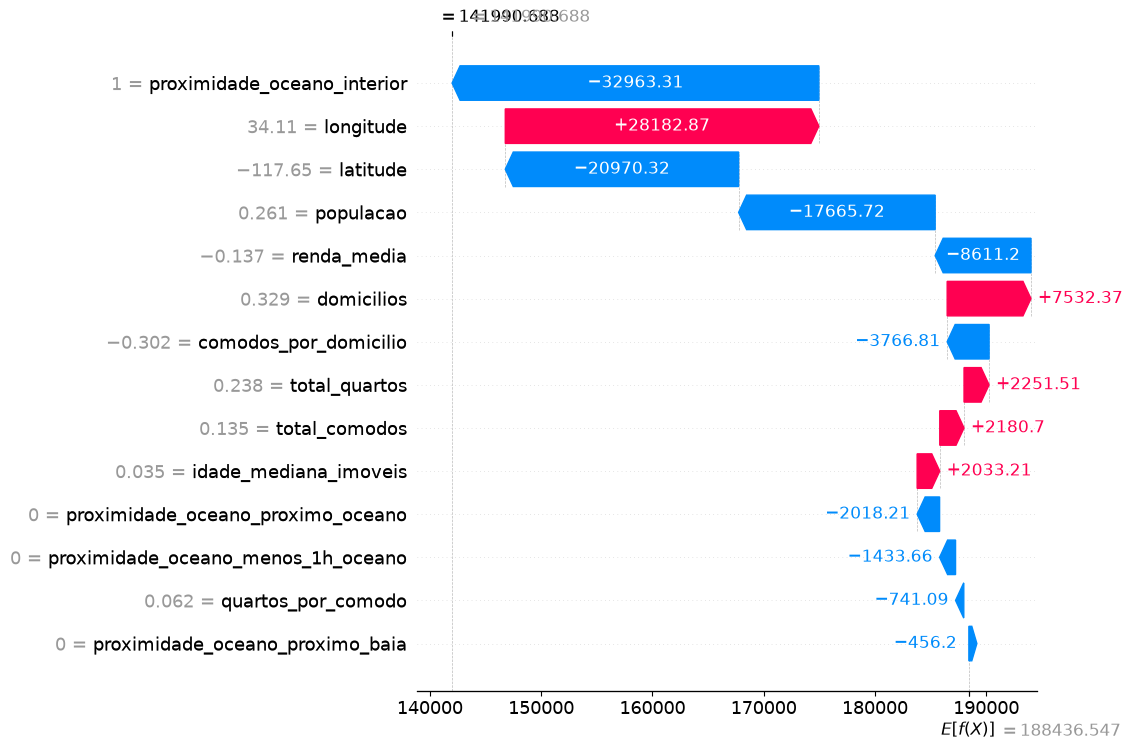

In [156]:
indice_imovel = 3

imovel_df = X_teste_fe.iloc[[indice_imovel]]
valor_real = y_teste.iloc[indice_imovel]
valor_previsto = modelo_xgb_optuna_100.predict(imovel_df)[0]

print(f"Valor Real -> {valor_real:.2f}")
print(f"Valor Previsto -> {valor_previsto:.2f}")

base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

explanation_cliente = shap.Explanation(
    values=shap_values[indice_imovel],
    base_values=base_value,
    data=imovel_df.iloc[0].values,
    feature_names=X_teste_fe.columns.tolist()
)

shap.plots.waterfall(explanation_cliente, max_display=14)

### Interpretação da Previsão Individual

Para o registro analisado, o valor real é de aproximadamente **US$ 176,6 mil**, enquanto o modelo estimou cerca de **US$ 142,0 mil**.

O valor de referência do modelo para esta observação parte de aproximadamente **US$ 188,4 mil**, e as contribuições SHAP mostram quais características aumentaram ou reduziram essa estimativa até chegar à previsão final.

Entre os principais fatores que **reduziram** o valor previsto estão:

- pertencer à categoria `interior`, com impacto de aproximadamente **-US$ 33,0 mil**;
- `latitude`, com impacto de cerca de **-US$ 21,0 mil**;
- `populacao`, com aproximadamente **-US$ 17,7 mil**;
- `renda_media`, com impacto próximo de **-US$ 8,6 mil**.

Por outro lado, `longitude` apresentou a principal contribuição positiva, elevando a previsão em aproximadamente **US$ 28,2 mil**. `domicilios`, `total_quartos`, `total_comodos` e `idade_mediana_imoveis` também contribuíram positivamente, porém com menor intensidade.

O exemplo evidencia que a previsão final resulta da combinação de diversos fatores geográficos, econômicos e habitacionais, e não da influência isolada de uma única variável.

#  22. Aplicação de Negócio

## Priorização Geográfica de Regiões Imobiliárias

Após a etapa de modelagem, o objetivo deste notebook é transformar o modelo em uma solução de apoio à decisão para análise regional do mercado imobiliário da Califórnia.

A proposta é utilizar as previsões do modelo para:

- estimar o valor mediano dos imóveis por região;
- segmentar o mercado em faixas de valor;
- identificar regiões compatíveis com um orçamento definido;
- visualizar espacialmente essas regiões por meio de longitude e latitude.

> Como o dataset representa regiões censitárias, a solução deve ser interpretada como uma ferramenta de análise regional e não como avaliação individual de imóveis.

## Base de Apoio à Decisão

Nesta etapa, as previsões do modelo são incorporadas à base original para formar uma tabela orientada ao negócio.

In [157]:
pred_teste = modelo_xgb_optuna_100.predict(X_teste_fe)

base_negocio = X_teste.copy()
base_negocio["valor_estimado"] = pred_teste

## Segmentação do Mercado

Para facilitar a leitura comercial, as regiões serão agrupadas em quatro segmentos de mercado com base no valor estimado pelo modelo.

In [158]:
base_negocio["segmento_mercado"] = pd.qcut(
    base_negocio["valor_estimado"],
    q=4,
    labels=["Econômico", "Intermediário", "Alto Padrão", "Premium"]
)

base_negocio[["valor_estimado", "segmento_mercado"]].head()

,valor_estimado,segmento_mercado
0,214052.703125,Alto Padrão
1,64920.101562,Econômico
2,216919.937500,Alto Padrão
3,141990.578125,Intermediário
4,393958.281250,Premium


## Mapa Analítico das Regiões

A visualização geográfica é uma das partes mais valiosas deste projeto, pois permite observar como o valor estimado se distribui espacialmente no território da Califórnia.

Cada ponto representa uma região, posicionada por longitude e latitude, e colorida de acordo com o valor estimado pelo modelo.

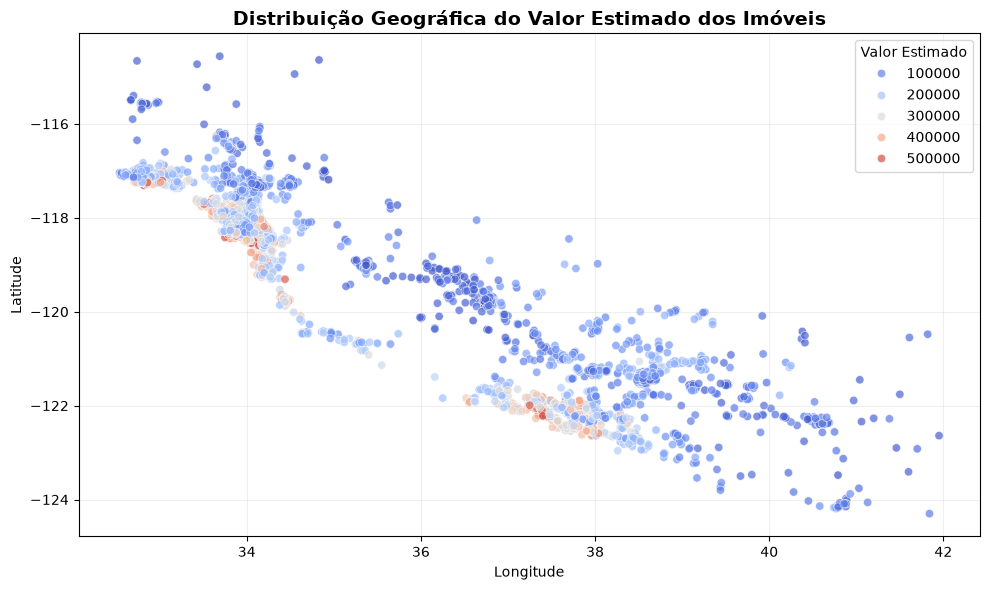

In [159]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=base_negocio, x="longitude", y="latitude", hue="valor_estimado", palette="coolwarm", alpha=0.7)

plt.title("Distribuição Geográfica do Valor Estimado dos Imóveis", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.legend(title="Valor Estimado")

plt.tight_layout()
plt.show()

## Análise por Orçamento

Uma aplicação direta da solução é filtrar regiões compatíveis com um orçamento máximo definido.

Isso permite reduzir o universo de análise e direcionar esforços comerciais para regiões alinhadas ao perfil desejado.

In [160]:
orcamento_maximo = 400000

regioes_compativeis = base_negocio[base_negocio["valor_estimado"] <= orcamento_maximo].copy()

regioes_compativeis["margem_orcamento"] = (orcamento_maximo - regioes_compativeis["valor_estimado"])

regioes_compativeis = regioes_compativeis.sort_values(by="valor_estimado", ascending=False)

regioes_compativeis[
    ["longitude", "latitude", "renda_media", "valor_estimado", "segmento_mercado", "margem_orcamento"]
].head(10)

,longitude,latitude,renda_media,valor_estimado,segmento_mercado,margem_orcamento
133,33.60,-117.87,1.441054,399195.34375,Premium,804.65625
3819,34.24,-118.23,1.982151,398474.87500,Premium,1525.12500
1334,34.13,-118.02,2.028907,398107.59375,Premium,1892.40625
552,37.36,-121.98,2.094060,397930.96875,Premium,2069.03125
323,32.71,-117.24,1.467727,397419.68750,Premium,2580.31250
2822,37.33,-122.04,2.046619,396909.59375,Premium,3090.40625
3268,34.03,-118.45,0.074528,396836.96875,Premium,3163.03125
2309,34.45,-119.78,1.366676,395689.28125,Premium,4310.71875
4092,37.90,-122.54,0.292969,395664.65625,Premium,4335.34375
3774,37.81,-122.45,0.011114,395598.81250,Premium,4401.18750


## Mapa das Regiões Compatíveis com o Orçamento

O gráfico abaixo destaca apenas as regiões cujo valor estimado está dentro do orçamento definido.

Essa visualização pode apoiar a priorização comercial, a seleção de áreas de atuação e a análise de mercados-alvo.

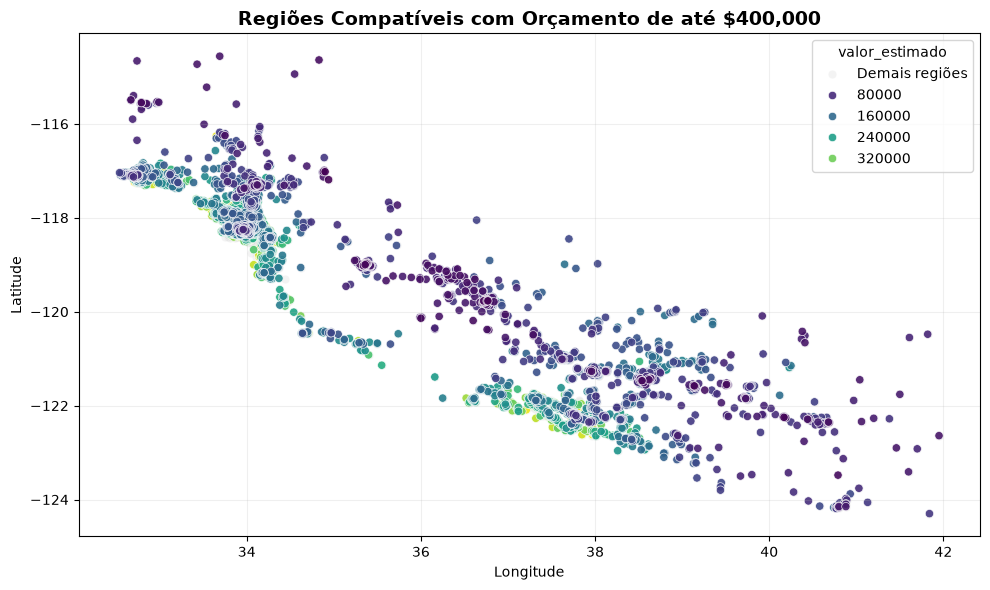

In [161]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=base_negocio, x="longitude", y="latitude", color="lightgray", alpha=0.25, label="Demais regiões")

sns.scatterplot(data=regioes_compativeis, x="longitude", y="latitude", hue="valor_estimado", palette="viridis", alpha=0.9)

plt.title(f"Regiões Compatíveis com Orçamento de até ${orcamento_maximo:,.0f}", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Resumo da Análise

A seguir, são apresentados indicadores simples para apoiar a leitura de negócio das regiões selecionadas.

In [162]:
print(f"Orçamento máximo: ${orcamento_maximo:,.2f}")
print(f"Quantidade de regiões compatíveis: {len(regioes_compativeis)}")
print(f"Valor médio estimado: ${regioes_compativeis['valor_estimado'].mean():,.2f}")
print(f"Valor mediano estimado: ${regioes_compativeis['valor_estimado'].median():,.2f}")

Orçamento máximo: $400,000.00
Quantidade de regiões compatíveis: 3909
Valor médio estimado: $187,016.83
Valor mediano estimado: $178,654.94


## Interpretabilidade da Estimativa

Além da análise geográfica, o modelo também pode explicar individualmente por que determinada região recebeu uma estimativa maior ou menor, por meio do SHAP.

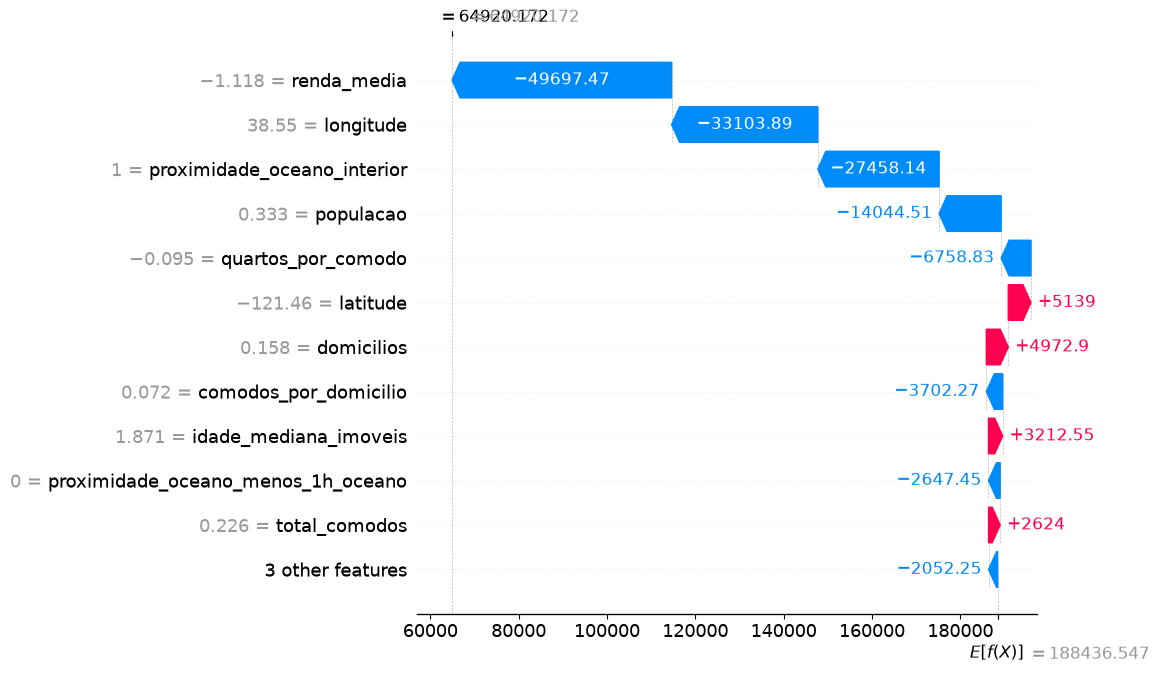

In [163]:
indice_imovel = 1
imovel_df = X_teste_fe.iloc[[indice_imovel]]

base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

explanation_cliente = shap.Explanation(
    values=shap_values[indice_imovel],
    base_values=base_value,
    data=imovel_df.iloc[0].values,
    feature_names=imovel_df.columns.tolist()
)

shap.plots.waterfall(explanation_cliente, max_display=12)

## Conclusão

A solução proposta transforma o modelo preditivo em uma ferramenta de apoio à decisão para o mercado imobiliário regional.

Com base nas previsões do modelo, foi possível:

- estimar o valor dos imóveis por região;
- segmentar o mercado em diferentes faixas;
- filtrar regiões compatíveis com um orçamento;
- visualizar espacialmente essas oportunidades com longitude e latitude;
- interpretar previsões individuais com SHAP.

A próxima etapa será transformar essa lógica em uma aplicação interativa com Streamlit.

# 23. Salvamento do Pipeline Final

Após a seleção, validação e interpretação do modelo, o pré-processamento e o XGBoost final são consolidados em um único `Pipeline`.

Essa estrutura garante que as mesmas transformações utilizadas durante o treinamento sejam aplicadas automaticamente durante novas previsões, reduzindo inconsistências entre o ambiente de desenvolvimento e a aplicação.

O pipeline é então persistido com `joblib` na pasta `models`, permitindo seu carregamento posterior pela aplicação desenvolvida com Streamlit.

In [164]:
pipeline_final = Pipeline(
    steps=[
        ("preprocessador", preprocessador_fe),
        ("modelo_final", modelo_xgb_optuna_100)
    ]
)

In [165]:
joblib.dump(pipeline_final, "../models/pipeline_completo.pkl")

['../models/pipeline_completo.pkl']

# 24. Conclusão da Modelagem

O processo de modelagem permitiu comparar diferentes algoritmos, estratégias de Feature Engineering, técnicas de otimização e modelos ensemble antes da definição da solução final.

O **XGBoost otimizado com Optuna em 100 trials** apresentou o melhor equilíbrio entre desempenho preditivo, regularização e capacidade de generalização. No conjunto de teste, o modelo alcançou aproximadamente:

- **R²:** 0,824;
- **MAE:** US$ 30,6 mil;
- **RMSE:** US$ 48,1 mil;
- **MAPE:** 15,9%.

Os resultados permaneceram próximos aos observados na Cross-Validation, que apresentou **R² médio de 0,827** e **MAE próximo de US$ 31,3 mil**, reforçando a estabilidade do pipeline em dados não utilizados durante o treinamento.

A Learning Curve também mostrou uma redução do gap entre treino e validação para aproximadamente **US$ 6,9 mil**, indicando menor overfitting após o aumento da regularização e um comportamento mais equilibrado do modelo.

As análises de Feature Importance e SHAP reforçaram a relevância de fatores como **renda média, localização geográfica e proximidade do oceano**, permitindo compreender tanto o comportamento global do modelo quanto previsões individuais.

Além da previsão de valores, os resultados foram transformados em uma solução de **inteligência geográfica aplicada ao mercado imobiliário**, permitindo identificar regiões compatíveis com diferentes critérios de orçamento, localização e posicionamento de mercado.

Por fim, o pré-processamento e o modelo final foram consolidados em um único pipeline e persistidos para utilização na aplicação desenvolvida com Streamlit, concluindo o fluxo do projeto desde a preparação dos dados até a disponibilização de uma solução analítica orientada ao negócio.